# Validation of the baseline panel with known asset-pricing results

If fundamentals, units and timing of the baseline panel are right, well-known results must appear. The
functions live in `src/datastream/validation.py`; this notebook configures and displays. Outputs go to
`OUTPUT_DIR`.

| Section | Test | What to expect |
|---|---|---|
| 1 | Fama-French factors rebuilt from the panel (2x3, NYSE breakpoints, June) vs. Ken French's factors | corr SMB >= 0.95, HML ~0.85-0.95, RMW/CMA ~0.8-0.9 |
| 2 | Fama-MacBeth regressions of next-month returns on characteristics | signs as in the literature (column `expected`) |
| 3 | Decile sorts, EW and VW | spreads with the same sign, roughly monotonic |
| 4 | Event study around report months, by earnings growth | most of the reaction before the availability month (report + lag); small drift after |

**Prerequisites** (Windows machine):
```
uv run python scripts/05_build_monthly_universe.py
uv run python scripts/06_build_baseline_panel.py                     # baseline_rolling_0.2
uv run python scripts/06_build_baseline_panel.py --convention ff     # baseline_ff_0.2 (section 1)
```
Literature benchmarks are approximate (other databases, samples and definitions); look for agreement in sign
and rough magnitude, and for large deviations.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from datastream import firm_evaluation as fe
from datastream import validation as va
from datastream.ff_data import get_ff_factors
from datastream.preprocessing.firm_data import read_registry

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
fe.set_style()

# ── configuration ───────────────────────────────────────────────────────────────────────────────────
REGION = "US"
FIRM_ROOT = Path(os.environ.get("DS_FIRM_ROOT", "D:/Datastream/Firmcharacteristics_Monthly")) / REGION
PRICE_PATH = Path(os.environ.get("DS_PRICE_PATH", "D:/Datastream/PriceData/US/processed"))
PENNY_PERCENTILE = "0.2"
BASELINE_ROLLING = FIRM_ROOT / "Paneldata" / "baseline" / f"baseline_rolling_{PENNY_PERCENTILE}.parquet"
BASELINE_FF = FIRM_ROOT / "Paneldata" / "baseline" / f"baseline_ff_{PENNY_PERCENTILE}.parquet"
STATICS_FILE = PRICE_PATH / f"statics_filtered_{PENNY_PERCENTILE}.csv"     # EXMNEM for NYSE breakpoints
INTEREST_VAR = None          # e.g. "WC01251" (interest expense) once downloaded; None: OP = operating income / BE
LAG_MONTHS = 3               # the lag used for BASELINE_ROLLING (marked in the event study)
HAC_LAGS = 6
SUBPERIODS = [("1994-2004", "1994-01", "2004-12"), ("2005-2014", "2005-01", "2014-12"), ("2015-", "2015-01", "2099-12")]
OUTPUT_DIR = FIRM_ROOT / "Paneldata" / "validation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
registry = read_registry(REPO / "config" / "firm_variables.csv")
signs = dict(zip(registry["variable"], registry.get("sign", pd.Series("", index=registry.index))))

C_MINE, C_FF = fe.CATEGORICAL[1], fe.CATEGORICAL[0]

## 0. Load

In [2]:
panel = pd.read_parquet(BASELINE_ROLLING)
print(f"Rolling panel: {len(panel):,} stock-months, {panel['DSCD'].nunique():,} stocks, "
      f"{panel['Date'].min():%Y-%m} to {panel['Date'].max():%Y-%m}")
statics = pd.read_csv(STATICS_FILE, dtype=str)
nyse = set(statics.loc[statics["EXMNEM"].str.upper().str.startswith("NYS", na=False), "DSCD"].str.strip())
print(f"NYSE stocks (current exchange from the statics): {len(nyse):,}")

ff3 = get_ff_factors(3, "monthly")
ff5 = get_ff_factors(5, "monthly")

Rolling panel: 1,349,605 stock-months, 12,327 stocks, 1993-10 to 2025-12
NYSE stocks (current exchange from the statics): 4,285


## 1. Fama-French factors rebuilt from the panel
Built from the panel with the Fama-French timing (`--convention ff`): portfolios formed at the end of June t
with market cap of June t; B/M = book equity of fiscal year t-1 / market cap of December t-1; OP = operating
income (minus interest expense if `INTEREST_VAR` is set) / book equity; INV = asset growth; NYSE breakpoints
(median size; 30th/70th percentiles); value-weighted returns July t to June t+1.

Known differences to Ken French's construction: Worldscope common equity instead of Compustat book equity
(deferred taxes, preferred stock), Datastream universe and filters instead of CRSP, current instead of
historical exchange listing for the NYSE breakpoints, and the OP approximation.

In [3]:
if BASELINE_FF.exists():
    panel_ff = pd.read_parquet(BASELINE_FF)
    factors = va.replicate_ff_factors(panel_ff, nyse, INTEREST_VAR)
    cmp3 = va.compare_factors(factors, ff3, {"SMB_BM": "SMB", "HML": "HML"}, HAC_LAGS)
    cmp5 = va.compare_factors(factors, ff5, {"SMB": "SMB", "RMW": "RMW", "CMA": "CMA"}, HAC_LAGS)
    comparison = pd.concat([cmp3.assign(model="FF3"), cmp5.assign(model="FF5")])
    comparison.to_csv(OUTPUT_DIR / "1_ff_factor_comparison.csv")
    factors.to_csv(OUTPUT_DIR / "1_replicated_factors.csv")
    display(comparison[["model", "french", "months", "corr", "mean_mine_annual", "mean_ff_annual", "t_mine", "t_ff",
                        "vol_mine_annual", "vol_ff_annual", "slope", "tracking_error_annual"]])
else:
    factors = None
    print(f"{BASELINE_FF.name} not found: run scripts/06_build_baseline_panel.py --convention ff")

,model,french,months,corr,mean_mine_annual,mean_ff_annual,t_mine,t_ff,vol_mine_annual,vol_ff_annual,slope,tracking_error_annual
factor,,,,,,,,,,,,
SMB_BM,FF3,SMB,378,0.9409,0.0014,0.0027,0.0908,0.1508,0.0943,0.1106,1.1032,0.0387
HML,FF3,HML,378,0.8896,0.0219,0.0141,1.1630,0.5735,0.0942,0.1152,1.0876,0.0533
SMB,FF5,SMB,378,0.9666,0.0129,0.0066,0.7899,0.3632,0.0949,0.1083,1.1034,0.0294
RMW,FF5,RMW,378,0.8705,0.0815,0.0397,4.2783,2.1619,0.1020,0.0943,0.8043,0.0505
CMA,FF5,CMA,378,0.6803,-0.0487,0.0183,-3.0372,1.2011,0.0840,0.0766,0.6204,0.0646


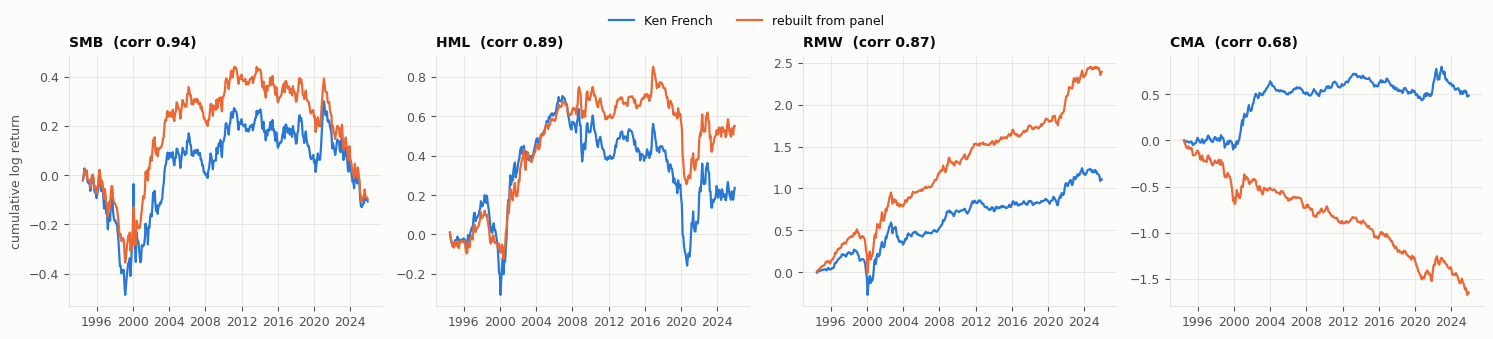

In [4]:
if factors is not None:
    pairs = [("SMB_BM", ff3, "SMB"), ("HML", ff3, "HML"), ("RMW", ff5, "RMW"), ("CMA", ff5, "CMA")]
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=False)
    for ax, (mine, ref, col) in zip(axes, pairs):
        x = pd.concat([factors[mine].rename("rebuilt"), ref[col].rename("Ken French")], axis=1, join="inner").dropna()
        cum = np.log1p(x).cumsum()
        idx = cum.index.to_timestamp()
        ax.plot(idx, cum["Ken French"], color=C_FF, label="Ken French")
        ax.plot(idx, cum["rebuilt"], color=C_MINE, label="rebuilt from panel")
        ax.set_title(f"{col}  (corr {x['rebuilt'].corr(x['Ken French']):.2f})", loc="left")
    axes[0].set_ylabel("cumulative log return")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.06))
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "1_factors_cumulative.png", dpi=130, bbox_inches="tight")
    plt.show()

## 2. Fama-MacBeth regressions
Monthly cross-sectional regressions of the return in month t+1 on characteristics known at the end of month t
(from the rolling panel: fundamentals available after the lag). Characteristics are winsorized at 1%/99% and
standardized per month, so coefficients are monthly returns per one cross-sectional standard deviation.
Newey-West t-statistics. Samples: all stocks, and without the smallest NYSE size quintile.

In [5]:
d = va.characteristics(panel, INTEREST_VAR)
xs = [c for c in va.CHARACTERISTICS if c in d.columns and d[c].notna().any()]
print("Characteristics:", xs)
print(d[xs].describe(percentiles=[0.01, 0.5, 0.99]).T[["count", "mean", "1%", "50%", "99%"]])

fm = {}
fm["all"], fm_coefs = va.fama_macbeth(d, xs, hac_lags=HAC_LAGS)
fm["no smallest quintile"], _ = va.fama_macbeth(d[d["size_group"] > 1], xs, hac_lags=HAC_LAGS)
for label, a, b in SUBPERIODS:
    fm[label], _ = va.fama_macbeth(d, xs, hac_lags=HAC_LAGS, start=a, end=pd.Period(b).end_time)
fm_table = pd.concat({k: v[["coef", "t_nw"]] for k, v in fm.items()}, axis=1)
fm_table.insert(0, "expected", fm["all"]["expected"])
fm_table.to_csv(OUTPUT_DIR / "2_fama_macbeth.csv")
print(f"All stocks: {fm['all'].attrs['avg_n']:.0f} stocks per month, average R2 {fm['all'].attrs['avg_r2']:.3f}")
display(fm_table)

Characteristics: ['log_me', 'log_bm', 'mom_12_2', 'str_1', 'op', 'ag', 'ep']
                  count    mean      1%     50%     99%
log_me   1,348,108.0000  6.5688  2.6891  6.4561 11.5247
log_bm   1,221,487.0000 -0.7657 -3.4757 -0.6649  1.2804
mom_12_2 1,131,347.0000  0.1533 -0.6730  0.0893  1.8848
str_1    1,319,318.0000  0.0105 -0.3489  0.0059  0.4175
op       1,219,718.0000  0.1622 -1.2919  0.1598  1.7196
ag       1,222,876.0000 42.3384 -0.3709  0.0729  3.5677
ep       1,258,139.0000  0.0210 -0.7270  0.0465  0.3814
All stocks: 2728 stocks per month, average R2 0.058


expected     all         no smallest quintile         1994-2004         2005-2014           2015-        
                                             coef    t_nw                 coef    t_nw      coef    t_nw      coef    t_nw    coef    t_nw
variable                                                                                                                                  
const                                      0.0109  4.3532               0.0105  4.1478    0.0146  4.0481    0.0091  1.7212  0.0093  2.3095
log_me           - (weak since the 1980s) -0.0006 -1.1392              -0.0009 -1.8501   -0.0015 -1.3257   -0.0000 -0.0726 -0.0001 -0.1873
log_bm               + (weak since ~2007)  0.0023  2.7653               0.0015  1.6422    0.0043  2.6042    0.0012  1.6290  0.0013  0.8708
mom_12_2  + (weak after 2000, 2009 crash) -0.0005 -0.5650              -0.0001 -0.1540    0.0020  1.3213   -0.0020 -1.0407 -0.0015 -1.8855
str_1                          - (robust) -0.0034 -5.5440              -0.0024 -3.7693   -0.0057 -5.4279   -0.0030 -3.2510 -0.0017 -1.6624
op                                      +  0.0024  3.6681               0.0017  2.3856    0.0038  2.4798    0.0020  3.5597  0.0014  1.4398
ag                                      -  0.0031  6.9446               0.0027  5.5205    0.0038  4.2423    0.0025  5.5950  0.0031  3.5997
ep                                      +  0.0048  8.6764               0.0045  7.4981    0.0055  6.4993    0.0052  5.0848  0.0037  4.0046

## 3. Decile sorts
Monthly deciles on each characteristic (all-stock breakpoints), equal- and value-weighted returns of month
t+1, and the D10-D1 spread with Newey-West t. A spread that only shows up equal-weighted is a small-cap effect.

In [6]:
sort_rows = {}
for c in xs:
    tab, _ = va.decile_sorts(d, c, hac_lags=HAC_LAGS)
    for w in ["EW", "VW"]:
        sort_rows[(c, w)] = tab.loc[w]
sorts = pd.DataFrame(sort_rows).T
sorts.index.names = ["characteristic", "weighting"]
sorts.to_csv(OUTPUT_DIR / "3_decile_sorts.csv")
display(sorts)

D1     D2     D3     D4     D5     D6     D7     D8     D9    D10  D10-D1    t_nw
characteristic weighting                                                                                       
log_me         EW         0.0112 0.0112 0.0112 0.0108 0.0112 0.0105 0.0099 0.0093 0.0093 0.0093 -0.0019 -1.1078
               VW         0.0110 0.0115 0.0112 0.0109 0.0111 0.0105 0.0099 0.0092 0.0092 0.0095 -0.0015 -0.8176
log_bm         EW         0.0056 0.0071 0.0079 0.0093 0.0098 0.0106 0.0113 0.0124 0.0152 0.0197  0.0141  4.4843
               VW         0.0096 0.0091 0.0089 0.0093 0.0092 0.0108 0.0099 0.0121 0.0134 0.0143  0.0047  1.7382
mom_12_2       EW         0.0102 0.0093 0.0105 0.0101 0.0102 0.0106 0.0103 0.0104 0.0109 0.0124  0.0022  0.6274
               VW         0.0072 0.0077 0.0105 0.0100 0.0091 0.0101 0.0092 0.0097 0.0090 0.0123  0.0051  1.2206
str_1          EW         0.0152 0.0125 0.0113 0.0115 0.0101 0.0103 0.0092 0.0082 0.0082 0.0077 -0.0075 -3.4975
               VW         0.0091 0.0117 0.0102 0.0112 0.0094 0.0098 0.0092 0.0085 0.0067 0.0092  0.0001  0.0371
op             EW         0.0007 0.0055 0.0079 0.0100 0.0118 0.0124 0.0137 0.0147 0.0154 0.0169  0.0162  4.5274
               VW         0.0002 0.0023 0.0058 0.0066 0.0081 0.0098 0.0097 0.0102 0.0112 0.0123  0.0121  2.9192
ag             EW         0.0007 0.0071 0.0085 0.0098 0.0104 0.0120 0.0127 0.0143 0.0153 0.0172  0.0165  7.0504
               VW         0.0034 0.0067 0.0078 0.0086 0.0080 0.0104 0.0100 0.0109 0.0143 0.0148  0.0114  4.1046
ep             EW         0.0014 0.0034 0.0039 0.0066 0.0084 0.0100 0.0123 0.0153 0.0196 0.0269  0.0255  8.3185
               VW        -0.0008 0.0008 0.0038 0.0074 0.0086 0.0113 0.0108 0.0135 0.0156 0.0207  0.0215  5.7458

## 4. Event study around report months
For annual reports (previous report 9-15 months earlier): earnings growth = (NI - NI_prev) / TA_prev, quintiles
per report year. Market-adjusted returns (minus the equal-weighted universe mean) from 3 months before to 12
months after the report month (month 0 = when Datastream changes the value, about one month after fiscal year
end). The dashed line marks the availability month of the rolling panel (report month + `LAG_MONTHS`).

Expected: earnings announcements and 10-K filings fall in the first months after fiscal year end, so most of
the return difference between high and low earnings growth should appear in months 0 to `LAG_MONTHS`-1 - which
the rolling panel does not use - and only a small drift (post-earnings-announcement drift) afterwards. A large
spread after the availability month would suggest a longer lag.

137,095 annual report events


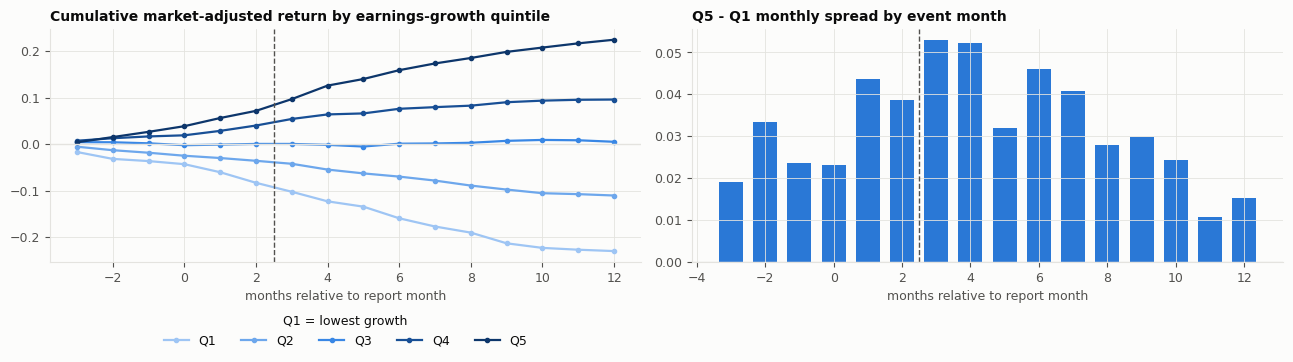

k,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10,11,12
spread,0.0191,0.0333,0.0236,0.0230,0.0436,0.0386,0.0529,0.0523,0.0319,0.0460,0.0409,0.0278,0.0297,0.0244,0.0106,0.0151
t,4.0415,7.2007,5.7986,5.5079,10.4186,10.1499,11.5090,10.8244,7.4296,9.8104,8.3609,5.5955,5.7457,5.4258,1.9410,3.0286
cohorts,365.0000,366.0000,368.0000,368.0000,369.0000,372.0000,372.0000,372.0000,371.0000,371.0000,372.0000,368.0000,366.0000,365.0000,364.0000,363.0000


,cum_spread,months
before report (-3..-1),0.0761,3.0000
report to availability (0..2),0.1053,3.0000
after availability (3..5),0.1371,3.0000
later (6..12),0.1944,7.0000


In [7]:
snaps = va.report_events(FIRM_ROOT, panel[["DSCD"]].drop_duplicates(), signs)
ev = va.event_study(snaps, panel[["DSCD", "Date", "ret"]], k_min=-3, k_max=12)
print(f"{ev['n_events']:,} annual report events")
cum = ev["by_group"].loc[-3:].cumsum()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
ramp = [fe.BLUE_RAMP[i] for i in (1, 2, 3, 5, 6)]
for g, colr in zip(cum.columns, ramp):
    axes[0].plot(cum.index, cum[g], color=colr, marker="o", ms=3, label=f"Q{int(g)}")
axes[0].set_title("Cumulative market-adjusted return by earnings-growth quintile", loc="left")
axes[0].legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18), title="Q1 = lowest growth")
sp = ev["spread"]
axes[1].bar(sp.index, sp["spread"], color=fe.CATEGORICAL[0], width=0.7)
axes[1].set_title("Q5 - Q1 monthly spread by event month", loc="left")
for ax in axes:
    ax.axvline(LAG_MONTHS - 0.5, color=fe.INK_MUTED, ls="--", lw=1)
    ax.axhline(0, color=fe.GRID, lw=1)
    ax.set_xlabel("months relative to report month")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "4_event_study.png", dpi=130, bbox_inches="tight")
plt.show()

windows = {"before report (-3..-1)": (-3, -1), f"report to availability (0..{LAG_MONTHS - 1})": (0, LAG_MONTHS - 1),
           f"after availability ({LAG_MONTHS}..{LAG_MONTHS + 2})": (LAG_MONTHS, LAG_MONTHS + 2),
           f"later ({LAG_MONTHS + 3}..12)": (LAG_MONTHS + 3, 12)}
win = va.window_returns(sp, windows)
display(sp.T)
display(win)
sp.to_csv(OUTPUT_DIR / "4_event_spread.csv")
win.to_csv(OUTPUT_DIR / "4_event_windows.csv")